# Setup

In [1]:
import json
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
from matplotlib.patches import Patch

import tensorflow as tf
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from geexhp import datavis

datavis.configure_matplotlib()

2026-02-26 01:23:56.935186: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-26 01:23:56.936875: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-26 01:23:56.948528: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-26 01:23:56.985578: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772079837.031905 3054860 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772079837.04

In [2]:
TELESCOPE = {
    "LUVOIR": dict(prefix="B", region_bins={"UV": 8, "Vis": 94, "NIR": 49}),
    "HABEX": dict(prefix="SS", region_bins={"UV": 7, "Vis": 109, "NIR": 25}),
}


def parse_example(
    example_proto,
    input_stats,
    output_stats,
    telescope: str = "LUVOIR",
):

    meta = TELESCOPE[telescope]
    pfx = meta["prefix"]
    bins = meta["region_bins"]

    raw_input_features = {
        f"NOISY_ALBEDO_{pfx}-{r}": tf.io.VarLenFeature(tf.float32)
        for r in ["NIR", "UV", "Vis"]
    }

    raw_output_features = {
        "OBJECT-RADIUS-REL-EARTH": tf.io.FixedLenFeature([], tf.float32),
        "OBJECT-GRAVITY": tf.io.FixedLenFeature([], tf.float32),
        "ATMOSPHERE-TEMPERATURE": tf.io.FixedLenFeature([], tf.float32),
        "ATMOSPHERE-PRESSURE": tf.io.FixedLenFeature([], tf.float32),
        "CH4": tf.io.FixedLenFeature([], tf.float32),
        "CO2": tf.io.FixedLenFeature([], tf.float32),
        "H2O": tf.io.FixedLenFeature([], tf.float32),
        "N2": tf.io.FixedLenFeature([], tf.float32),
        "O2": tf.io.FixedLenFeature([], tf.float32),
        "O3": tf.io.FixedLenFeature([], tf.float32),
        "Earth_type": tf.io.FixedLenFeature([], tf.string),
    }

    all_features = {**raw_input_features, **raw_output_features}
    parsed = tf.io.parse_single_example(example_proto, all_features)

    normalized_inputs = {}
    for region in ["UV", "Vis", "NIR"]:
        spectrum = parsed[f"NOISY_ALBEDO_{pfx}-{region}"]
        if isinstance(spectrum, tf.SparseTensor):
            spectrum = tf.sparse.to_dense(spectrum, default_value=0.0)

        mean = input_stats[region][0]
        std = input_stats[region][1]
        normalized = (spectrum - mean) / std

        normalized = tf.reshape(normalized, [bins[region], 1])
        normalized_inputs[f"NOISY_ALBEDO_{pfx}-{region}"] = normalized

    physical_outputs = []
    main_chemical_outputs = []
    other_chemical_outputs = []

    for param in [
        "OBJECT-RADIUS-REL-EARTH",
        "OBJECT-GRAVITY",
        "ATMOSPHERE-TEMPERATURE",
        "ATMOSPHERE-PRESSURE",
    ]:
        val = parsed[param]
        # To avoid a very ponctual error we found
        # the floating point precision error generates a single NaN value here :(
        if val == 273.15:
            val += 0.00002
        min_ = output_stats["physical_output_stats"][param][0]
        max_ = output_stats["physical_output_stats"][param][1]
        best_n = output_stats["physical_output_stats"][param][2]
        processed = (val - min_) / (max_ - min_)
        processed = tf.math.pow(float(processed), float(1 / best_n))
        physical_outputs.append(processed)

    for chem in ["O2", "O3"]:
        val = parsed[chem]
        best_n = output_stats["chemical_output_stats"][chem]["best_n"]
        processed = tf.math.pow(float(val), float(1 / best_n))
        main_chemical_outputs.append(processed)

    for chem in ["CH4", "CO2", "H2O", "N2"]:
        val = parsed[chem]
        best_n = output_stats["chemical_output_stats"][chem]["best_n"]
        processed = tf.math.pow(float(val), float(1 / best_n))
        other_chemical_outputs.append(processed)

    grouped_outputs = {
        "physical_output": physical_outputs,  # shape (4,)
        "main_chemical_output": main_chemical_outputs,  # shape (2,)
        "other_chemical_output": other_chemical_outputs,  # shape (7,)
        "earth_type": parsed["Earth_type"],  # shape (1,)
    }

    return normalized_inputs, grouped_outputs


def read_tfrecord(
    file_path,
    telescope="LUVOIR",
    batch_size=1024,
    shuffle_buffer=None,
    repeat=False,
):

    meta = TELESCOPE[telescope]
    pfx = meta["prefix"]

    with open("../data/normalization_stats.json") as f:
        stats = json.load(f)

    input_stats = {
        r: (stats["inputs"][f"{pfx}-{r}"]["mean"], stats["inputs"][f"{pfx}-{r}"]["std"])
        for r in ["UV", "Vis", "NIR"]
    }

    physical_keys = [
        "OBJECT-RADIUS-REL-EARTH",
        "OBJECT-GRAVITY",
        "ATMOSPHERE-TEMPERATURE",
        "ATMOSPHERE-PRESSURE",
    ]
    physical_output_stats = {
        key: (
            stats["outputs"][key]["min"],
            stats["outputs"][key]["max"],
            stats["outputs"][key]["best_n"],
        )
        for key in physical_keys
    }

    chemical_keys = ["CH4", "CO2", "H2O", "N2", "O2", "O3"]
    chemical_output_stats = {key: stats["outputs"][key] for key in chemical_keys}

    output_stats = {
        "physical_output_stats": physical_output_stats,
        "chemical_output_stats": chemical_output_stats,
    }

    dataset = tf.data.TFRecordDataset(file_path, num_parallel_reads=tf.data.AUTOTUNE)

    if shuffle_buffer is not None and shuffle_buffer > 0:
        dataset = dataset.shuffle(buffer_size=shuffle_buffer)

    parsed_dataset = dataset.map(
        lambda x: parse_example(x, input_stats, output_stats, telescope=telescope),
        num_parallel_calls=tf.data.AUTOTUNE,
    )

    if repeat:
        parsed_dataset = parsed_dataset.repeat()

    parsed_dataset = parsed_dataset.batch(batch_size, drop_remainder=False)
    parsed_dataset = parsed_dataset.prefetch(tf.data.AUTOTUNE)

    return parsed_dataset

In [4]:
with open("../data/normalization_stats.json") as f:
    stats = json.load(f)


def denorm_physical(processed, name):
    """processed is 1-D array in (0-1)**(1/n) space."""
    pmin, pmax, n = (stats["outputs"][name][k] for k in ("min", "max", "best_n"))
    return (processed**n) * (pmax - pmin) + pmin


def denorm_chem(processed, name):
    """processed is (val)**(1/n) space."""
    n = stats["outputs"][name]["best_n"]
    return processed**n


def safe_log10(series):
    arr = series.to_numpy(dtype=float)
    out = np.full(arr.shape, np.nan, dtype=float)
    pos_mask = arr > 0
    if pos_mask.any():
        out[pos_mask] = np.log10(arr[pos_mask])

    return pd.Series(out, index=series.index)


def get_predictions(ds, model):
    phys_cols = ["RADIUS_REL_EARTH", "GRAVITY", "TEMP", "PRESSURE"]
    main_chem_cols = ["O2", "O3"]
    other_chem_cols = ["CH4", "CO2", "H2O", "N2"]

    y_true_phys_all = []
    y_true_main_all = []
    y_true_other_all = []
    y_pred_phys_all = []
    y_pred_main_all = []
    y_pred_other_all = []
    earth_types_all = []

    for x_batch, y_batch in ds:
        preds = model(x_batch, training=False)
        y_true_phys_all.append(y_batch["physical_output"].numpy())
        y_true_main_all.append(y_batch["main_chemical_output"].numpy())
        y_true_other_all.append(y_batch["other_chemical_output"].numpy())
        y_pred_phys_all.append(preds["physical_output"].numpy())
        y_pred_main_all.append(preds["main_chemical_output"].numpy())
        y_pred_other_all.append(preds["other_chemical_output"].numpy())
        earth_types_all.append(y_batch["earth_type"].numpy())

    y_true_phys_all = np.concatenate(y_true_phys_all, axis=0)
    y_true_main_all = np.concatenate(y_true_main_all, axis=0)
    y_true_other_all = np.concatenate(y_true_other_all, axis=0)
    y_pred_phys_all = np.concatenate(y_pred_phys_all, axis=0)
    y_pred_main_all = np.concatenate(y_pred_main_all, axis=0)
    y_pred_other_all = np.concatenate(y_pred_other_all, axis=0)
    earth_types_all = np.concatenate(earth_types_all).astype("U")

    true_phys_cols = [f"true_{c}" for c in phys_cols]
    pred_phys_cols = [f"pred_{c}" for c in phys_cols]
    true_main_cols = [f"true_{c}" for c in main_chem_cols]
    pred_main_cols = [f"pred_{c}" for c in main_chem_cols]
    true_other_cols = [f"true_{c}" for c in other_chem_cols]
    pred_other_cols = [f"pred_{c}" for c in other_chem_cols]

    df = pd.concat(
        [
            pd.Series(earth_types_all, name="earth_type"),
            pd.DataFrame(y_true_phys_all, columns=true_phys_cols),
            pd.DataFrame(y_pred_phys_all, columns=pred_phys_cols),
            pd.DataFrame(y_true_main_all, columns=true_main_cols),
            pd.DataFrame(y_pred_main_all, columns=pred_main_cols),
            pd.DataFrame(y_true_other_all, columns=true_other_cols),
            pd.DataFrame(y_pred_other_all, columns=pred_other_cols),
        ],
        axis=1,
    )

    physical_key_map = {
        "RADIUS_REL_EARTH": "OBJECT-RADIUS-REL-EARTH",
        "GRAVITY": "OBJECT-GRAVITY",
        "TEMP": "ATMOSPHERE-TEMPERATURE",
        "PRESSURE": "ATMOSPHERE-PRESSURE",
    }

    for short_name, json_key in physical_key_map.items():
        true_col = f"true_{short_name}"
        pred_col = f"pred_{short_name}"
        new_true_col = f"{true_col}_original"
        new_pred_col = f"{pred_col}_original"
        df[new_true_col] = denorm_physical(df[true_col], json_key)
        df[new_pred_col] = denorm_physical(df[pred_col], json_key)

    all_chem_cols = main_chem_cols + other_chem_cols
    for chem_name in all_chem_cols:
        true_col = f"true_{chem_name}"
        pred_col = f"pred_{chem_name}"
        new_true_col = f"{true_col}_original"
        new_pred_col = f"{pred_col}_original"
        df[new_true_col] = denorm_chem(df[true_col], chem_name)
        df[new_pred_col] = denorm_chem(df[pred_col], chem_name)

    sigma = {}
    all_features = phys_cols + main_chem_cols + other_chem_cols
    for feat in all_features:
        true_col = f"true_{feat}_original"
        pred_col = f"pred_{feat}_original"
        res = df[pred_col] - df[true_col]
        sigma[feat] = res.std(ddof=1)
        df[f"sigma_{feat}_original"] = (res / sigma[feat]).abs()

    sigma_log = {}
    for feat in all_chem_cols:
        true_lin = df[f"true_{feat}_original"]
        pred_lin = df[f"pred_{feat}_original"]
        df[f"true_{feat}_log"] = safe_log10(true_lin)
        df[f"pred_{feat}_log"] = safe_log10(pred_lin)
        res_log = df[f"pred_{feat}_log"] - df[f"true_{feat}_log"]
        valid_res = res_log.dropna()
        sigma = valid_res.std(ddof=1)
        sigma_log[feat] = sigma if sigma > 0 else np.nan
        df[f"sigma_{feat}_log"] = (res_log / sigma_log[feat]).abs()

    return df

# Reading test set and loading the model 

In [5]:
PATH = "../data/test.tfrecord"

luvoir_ds = (
    read_tfrecord(PATH, telescope="LUVOIR", batch_size=1024)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)
habex_ds = (
    read_tfrecord(PATH, telescope="HABEX", batch_size=1024)
    .cache()
    .prefetch(tf.data.AUTOTUNE)
)

model_LUVOIR = tf.keras.models.load_model("../models/luvoir_model.keras")
model_HABEX = tf.keras.models.load_model("../models/habex_model.keras")

2026-02-26 01:24:15.780492: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Get results

In [ ]:
results_df_LUVOIR = get_predictions(luvoir_ds, model_LUVOIR)
results_df_HABEX = get_predictions(habex_ds, model_HABEX)

2026-02-26 01:24:21.190439: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-02-26 01:24:29.682816: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-02-26 01:24:36.954823: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# Table (Performance metrics)

In [7]:
def _mape_percent(y_true, y_pred, eps=0.0):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    if eps == 0.0:
        mask = y_true != 0
        if mask.sum() == 0:
            return np.nan
        denom = np.abs(y_true[mask])
        return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / denom)) * 100.0)
    else:
        denom = np.maximum(np.abs(y_true), eps)
        return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100.0)


def _wape_percent(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    num = np.sum(np.abs(y_true - y_pred))
    den = np.sum(np.abs(y_true))
    if den < eps:
        return np.nan
    return float((num / den) * 100.0)


def compute_metrics_from_results_df(
    df,
    targets,
    true_suffix="true_",
    pred_suffix="pred_",
    mape_eps=0.0,
):
    rows = []
    for t in targets:
        y_true = df[f"{true_suffix}{t}"].to_numpy(dtype=float)
        y_pred = df[f"{pred_suffix}{t}"].to_numpy(dtype=float)

        r2 = r2_score(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape = _mape_percent(y_true, y_pred, eps=mape_eps)
        wape = _wape_percent(y_true, y_pred)

        rows.append(
            dict(
                Target=t,
                R2=r2,
                MAE=mae,
                RMSE=rmse,
                **{"MAPE (%)": mape, "WAPE (%)": wape},
                N=len(y_true),
            )
        )

    out = pd.DataFrame(rows).set_index("Target")
    return out

In [8]:
PHYS_FEATS = ["RADIUS_REL_EARTH", "GRAVITY", "TEMP", "PRESSURE"]
CHEM_FEATS = ["CH4", "CO2", "H2O", "N2", "O2", "O3"]

In [9]:
luvoir_metrics_phys = compute_metrics_from_results_df(results_df_LUVOIR, PHYS_FEATS)
luvoir_metrics_phys.T

Target,RADIUS_REL_EARTH,GRAVITY,TEMP,PRESSURE
R2,0.830516,0.828558,0.500418,0.818249
MAE,0.067219,0.067887,0.106154,0.077094
RMSE,0.089197,0.089605,0.140055,0.102015
MAPE (%),13.142828,16.395353,351.021453,18.743863
WAPE (%),9.604589,10.426453,43.983973,13.680081
N,10826.000000,10826.000000,10826.000000,10826.000000


In [10]:
habex_metrics_phys = compute_metrics_from_results_df(results_df_HABEX, PHYS_FEATS)
habex_metrics_phys.T

Target,RADIUS_REL_EARTH,GRAVITY,TEMP,PRESSURE
R2,0.837331,0.833460,0.376984,0.826408
MAE,0.065357,0.066448,0.123654,0.075010
RMSE,0.087385,0.088315,0.156402,0.099699
MAPE (%),12.459457,14.725937,532.076127,17.925558
WAPE (%),9.338589,10.205317,51.235104,13.310114
N,10826.000000,10826.000000,10826.000000,10826.000000


In [11]:
luvoir_metrics_chem = compute_metrics_from_results_df(results_df_LUVOIR, CHEM_FEATS)
luvoir_metrics_chem.T

Target,CH4,CO2,H2O,N2,O2,O3
R2,0.983166,0.950923,0.972925,0.940724,0.981821,0.995692
MAE,0.016177,0.028385,0.014770,0.046276,0.021567,0.004069
RMSE,0.021331,0.040686,0.020556,0.075132,0.038957,0.010807
MAPE (%),7.269515,12.618833,5.116142,23.239397,18.130140,1.787608
WAPE (%),4.837451,9.954123,4.749814,6.611059,9.604986,1.779509
N,10826.000000,10826.000000,10826.000000,10826.000000,10826.000000,10826.000000


In [12]:
habex_metrics_chem = compute_metrics_from_results_df(results_df_HABEX, CHEM_FEATS)
habex_metrics_chem.T

Target,CH4,CO2,H2O,N2,O2,O3
R2,0.980294,0.957466,0.963796,0.937989,0.979988,0.995757
MAE,0.017432,0.025885,0.017538,0.045556,0.022671,0.004082
RMSE,0.023078,0.037877,0.023770,0.076845,0.040874,0.010725
MAPE (%),7.842255,12.287050,5.961731,29.502171,19.904616,1.948327
WAPE (%),5.212680,9.077590,5.639952,6.508115,10.096623,1.784814
N,10826.000000,10826.000000,10826.000000,10826.000000,10826.000000,10826.000000


# True zeros

In [13]:
def get_stats_O2O3(df, gases=("O2", "O3")):
    """
    Stats for the subset where true_gas_original == 0:
    - counts of exact-zero predictions (correct) vs nonzero (incorrect)
    - summary stats over all preds in the true-zero subset
    - summary stats over only the incorrect (nonzero) preds
    """
    out = {}

    for gas in gases:
        true_col = f"true_{gas}_original"
        pred_col = f"pred_{gas}_original"

        mask_zero = df[true_col] == 0
        preds = df.loc[mask_zero, pred_col].dropna()

        N = int(preds.shape[0])
        if N == 0:
            out[gas] = {
                "N_true0": 0,
                "n_pred_eq_0": 0,
                "pct_pred_eq_0": np.nan,
                "n_pred_neq_0": 0,
                "mean_all": np.nan,
                "std_all": np.nan,
                "median_all": np.nan,
                "rmse_all": np.nan,
                "mean_incorrect": np.nan,
                "std_incorrect": np.nan,
                "median_incorrect": np.nan,
                "rmse_incorrect": np.nan,
                "min_incorrect": np.nan,
                "max_incorrect": np.nan,
                "n_pred_lt_0": 0,
                "n_pred_gt_0": 0,
            }
            continue

        correct = preds == 0  # exact equality, no tolerance
        incorrect = preds != 0

        preds_incorrect = preds[incorrect]

        out[gas] = {
            "N_true0": N,
            "n_pred_eq_0": int(correct.sum()),
            "pct_pred_eq_0": float(correct.mean() * 100.0),
            "n_pred_neq_0": int(incorrect.sum()),
            # stats over ALL predictions when True=0
            "mean_all": float(preds.mean()),
            "std_all": float(preds.std(ddof=1)) if N > 1 else np.nan,
            "median_all": float(preds.median()),
            "rmse_all": float(np.sqrt(np.mean(preds.to_numpy() ** 2))),
            # stats over ONLY the incorrect ones (pred != 0)
            "mean_incorrect": (
                float(preds_incorrect.mean()) if preds_incorrect.size else np.nan
            ),
            "std_incorrect": (
                float(preds_incorrect.std(ddof=1))
                if preds_incorrect.size > 1
                else np.nan
            ),
            "median_incorrect": (
                float(preds_incorrect.median()) if preds_incorrect.size else np.nan
            ),
            "rmse_incorrect": (
                float(np.sqrt(np.mean(preds_incorrect.to_numpy() ** 2)))
                if preds_incorrect.size
                else np.nan
            ),
            "min_incorrect": (
                float(preds_incorrect.min()) if preds_incorrect.size else np.nan
            ),
            "max_incorrect": (
                float(preds_incorrect.max()) if preds_incorrect.size else np.nan
            ),
            # sign breakdown (can help diagnose weird behavior)
            "n_pred_lt_0": int((preds < 0).sum()),
            "n_pred_gt_0": int((preds > 0).sum()),
        }

    return pd.DataFrame.from_dict(out, orient="index")

In [14]:
stats_habex = get_stats_O2O3(results_df_HABEX)
stats_luvoir = get_stats_O2O3(results_df_LUVOIR)

print("HABEX")
display(stats_habex.T)

print("LUVOIR")
display(stats_luvoir.T)

HABEX


,O2,O3
N_true0,3.412000e+03,3.412000e+03
n_pred_eq_0,3.411000e+03,3.395000e+03
pct_pred_eq_0,9.997069e+01,9.950176e+01
n_pred_neq_0,1.000000e+00,1.700000e+01
mean_all,8.128927e-08,1.252436e-17
std_all,4.748295e-06,6.923503e-16
median_all,0.000000e+00,0.000000e+00
rmse_all,4.748295e-06,6.923621e-16
mean_incorrect,2.773590e-04,2.513712e-15
std_incorrect,NaN,9.772972e-15


LUVOIR


,O2,O3
N_true0,3.412000e+03,3.412000e+03
n_pred_eq_0,3.406000e+03,3.375000e+03
pct_pred_eq_0,9.982415e+01,9.891559e+01
n_pred_neq_0,6.000000e+00,3.700000e+01
mean_all,3.497353e-07,3.606954e-13
std_all,1.454169e-05,1.131533e-11
median_all,0.000000e+00,0.000000e+00
rmse_all,1.454377e-05,1.131942e-11
mean_incorrect,1.988828e-04,3.326196e-11
std_incorrect,3.112504e-04,1.049129e-10


In [15]:
results_df_LUVOIR[
    (results_df_LUVOIR["true_O3_original"] == 0)
    & (results_df_LUVOIR["pred_O3_original"] != 0)
][["true_O3", "true_O3_log", "pred_O3_log", "pred_O3_original"]].shape

(37, 4)

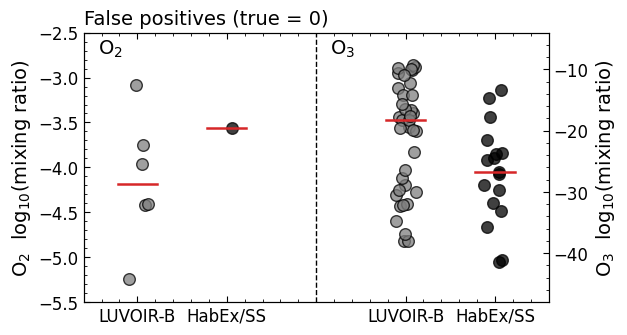

In [20]:
def get_leaks(df, gas):
    true_col = f"true_{gas}_original"
    pred_col = f"pred_{gas}_original"
    mask = (df[true_col] == 0) & (df[pred_col] != 0)
    return df.loc[mask, pred_col].values


leaks = {
    ("LU", "O2"): get_leaks(results_df_LUVOIR, "O2"),
    ("HB", "O2"): get_leaks(results_df_HABEX, "O2"),
    ("LU", "O3"): get_leaks(results_df_LUVOIR, "O3"),
    ("HB", "O3"): get_leaks(results_df_HABEX, "O3"),
}

C_LU = "tab:gray"
C_HB = "k"
RNG = np.random.default_rng(42)

fig, ax_o2 = plt.subplots(figsize=(6, 3.5))
ax_o3 = ax_o2.twinx()

x_o2 = np.array([0.0, 1.0])  # O2: LU, HB
x_o3 = np.array([3.0, 4.0])  # O3: LU, HB
labels = ["LUVOIR-B", "HabEx/SS"]

n_y_o2 = {("LU", "O2"): -2.9, ("HB", "O2"): -2.9}
n_y_o3 = {("LU", "O3"): -8.0, ("HB", "O3"): -8.0}

ax_o2.axvline(2.0, linestyle="--", linewidth=1.0, zorder=1, color="k")

for x0, key, color in zip(x_o2, [("LU", "O2"), ("HB", "O2")], [C_LU, C_HB]):
    data = leaks[key]
    if len(data) == 0:
        continue
    y = np.log10(data)
    jitter = RNG.uniform(-0.12, 0.12, len(y))

    ax_o2.scatter(
        x0 + jitter,
        y,
        color=color,
        s=70,
        alpha=0.75,
        edgecolors="k",
        zorder=4,
    )
    ax_o2.plot(
        [x0 - 0.22, x0 + 0.22],
        [np.median(y), np.median(y)],
        color="tab:red",
        linewidth=1.8,
        zorder=5,
    )

for x0, key, color in zip(x_o3, [("LU", "O3"), ("HB", "O3")], [C_LU, C_HB]):
    data = leaks[key]
    if len(data) == 0:
        continue
    y = np.log10(data)
    jitter = RNG.uniform(-0.12, 0.12, len(y))

    ax_o3.scatter(
        x0 + jitter,
        y,
        color=color,
        s=70,
        alpha=0.75,
        edgecolors="k",
        zorder=4,
    )
    ax_o3.plot(
        [x0 - 0.22, x0 + 0.22],
        [np.median(y), np.median(y)],
        color="tab:red",
        linewidth=1.8,
        zorder=5,
    )

ax_o2.text(
    -0.3,
    0.9,
    "O$_2$",
    transform=ax_o2.get_xaxis_transform(),
    ha="center",
    va="bottom",
)

ax_o2.text(
    2.3,
    0.9,
    "O$_3$",
    transform=ax_o2.get_xaxis_transform(),
    ha="center",
    va="bottom",
)

ax_o2.set_xlim(-0.6, 4.6)
ax_o2.set_xticks([0, 1, 3, 4])
ax_o2.set_xticklabels([labels[0], labels[1], labels[0], labels[1]])

ax_o2.set_ylim(-5.5, -2.5)
ax_o3.set_ylim(-48, -4)

ax_o2.set_ylabel("O$_2$  log$_{10}$(mixing ratio)")
ax_o3.set_ylabel("O$_3$  log$_{10}$(mixing ratio)")

ax_o2.set_title("False positives (true = 0)", loc="left")


plt.savefig("../images/exactly_zeros.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Pred vs true plot

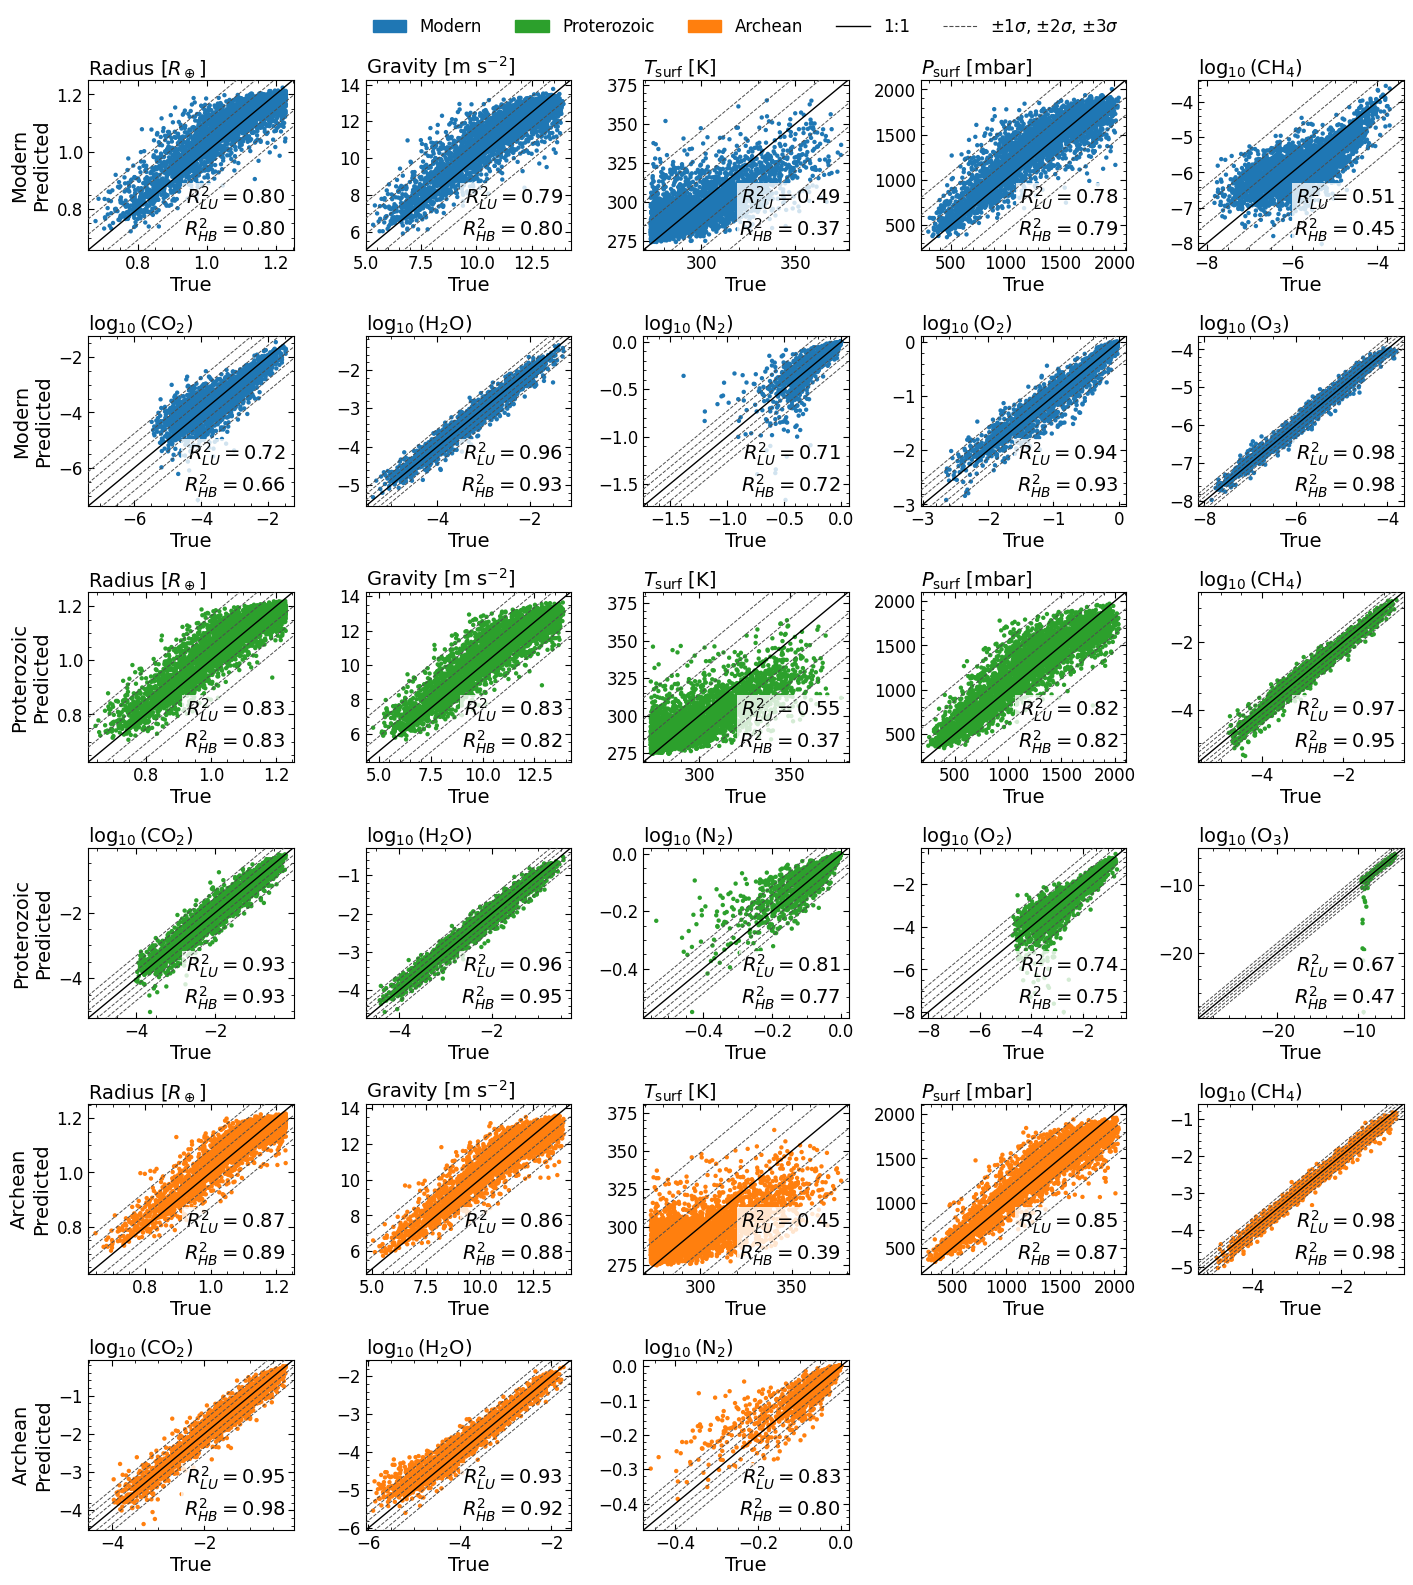

In [31]:
ERA_ORDER = ["modern", "proterozoic", "archean"]
ERA_TITLES = {"modern": "Modern", "proterozoic": "Proterozoic", "archean": "Archean"}
ERA_COLORS = {"modern": "tab:blue", "proterozoic": "tab:green", "archean": "tab:orange"}
ALL_FEATS = PHYS_FEATS + CHEM_FEATS

# Split into two rows of 5 each
ROW0_FEATS = ALL_FEATS[:5]  # RADIUS, GRAVITY, TEMP, PRESSURE, CH4
ROW1_FEATS = ALL_FEATS[5:]  # CO2, H2O, N2, O2, O3

N_COLS = 5

EXCLUDE = {"archean": {"O2", "O3"}}

FEAT_LABELS = {
    "RADIUS_REL_EARTH": r"Radius [$R_\oplus$]",
    "GRAVITY": r"Gravity [m s$^{-2}$]",
    "TEMP": r"$T_\mathrm{surf}$ [K]",
    "PRESSURE": r"$P_\mathrm{surf}$ [mbar]",
    "CH4": r"$\log_{10}(\mathrm{CH_4})$",
    "CO2": r"$\log_{10}(\mathrm{CO_2})$",
    "H2O": r"$\log_{10}(\mathrm{H_2O})$",
    "N2": r"$\log_{10}(\mathrm{N_2})$",
    "O2": r"$\log_{10}(\mathrm{O_2})$",
    "O3": r"$\log_{10}(\mathrm{O_3})$",
}


def _get_cols(feat):
    if feat in PHYS_FEATS:
        return f"true_{feat}_original", f"pred_{feat}_original"
    return f"true_{feat}_log", f"pred_{feat}_log"


def _xy(df, era, feat):
    tc, pc = _get_cols(feat)
    sub = df[df["earth_type"].astype(str).str.lower() == era]
    x = sub[tc].to_numpy(dtype=float)
    y = sub[pc].to_numpy(dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    return x[m], y[m]


def _safe_r2(x, y):
    return np.nan if x.size < 2 else r2_score(x, y)


def _sigma(arr):
    v = arr[np.isfinite(arr)]
    if v.size < 2:
        return np.nan
    s = float(np.std(v, ddof=1))
    return s if s > 0 else np.nan


def _lims(x, y, pad=0.04):
    lo = np.nanmin([x.min(), y.min()])
    hi = np.nanmax([x.max(), y.max()])
    if not (np.isfinite(lo) and np.isfinite(hi)):
        return None
    d = max(hi - lo, 1e-9)
    return lo - pad * d, hi + pad * d


def _fmt(v, nd=2):
    return "-" if not np.isfinite(v) else f"{v:.{nd}f}"


def _build_grid(n_era=3, n_rows_per_era=2, n_cols=5, fig_w=14, row_h=2.6, era_gap=0.55):
    total_rows = n_era * n_rows_per_era
    total_h = total_rows * row_h

    fig = plt.figure(figsize=(fig_w, total_h))
    grid = gridspec.GridSpec(
        total_rows,
        n_cols,
        figure=fig,
        hspace=era_gap,
        wspace=0.35,
        left=0.05,
        right=0.99,
        top=0.97,
        bottom=0.04,
    )

    era_axes = []
    for era_idx in range(n_era):
        rows_axes = []
        for r in range(n_rows_per_era):
            global_row = era_idx * n_rows_per_era + r
            col_axes = []
            for c in range(n_cols):
                ax = fig.add_subplot(grid[global_row, c])
                col_axes.append(ax)
            rows_axes.append(col_axes)
        era_axes.append(rows_axes)

    return fig, era_axes


def _draw_pred_true_panel(
    ax,
    xL,
    yL,
    xH,
    yH,
    feat,
    era,
    sigma_levels=(1, 2, 3),
    is_top_row=False,
):
    color = ERA_COLORS[era]
    SCATTER_KW = dict(s=10, edgecolors="none", rasterized=True)

    ax.scatter(xL, yL, color=color, **SCATTER_KW)

    lims = _lims(xL, yL)
    if lims is None:
        ax.axis("off")
        return

    ax.plot(lims, lims, color="k", lw=1.0, zorder=5)

    sL = _sigma(yL - xL)
    if np.isfinite(sL):
        for s in sigma_levels:
            for sign in (+1, -1):
                ax.plot(
                    lims,
                    (lims[0] + sign * s * sL, lims[1] + sign * s * sL),
                    ls="--",
                    lw=0.7,
                    color="0.30",
                    zorder=4,
                )

    ax.set_xlim(lims)
    ax.set_ylim(lims)

    r2L = _safe_r2(xL, yL)
    r2H = _safe_r2(xH, yH)

    ax.text(
        0.96,
        0.04,
        rf"$R^2_{{LU}}={_fmt(r2L)}$" + "\n" + rf"$R^2_{{HB}}={_fmt(r2H)}$",
        transform=ax.transAxes,
        va="bottom",
        ha="right",
        bbox=dict(facecolor="white", alpha=0.80, edgecolor="none", pad=1.5),
    )

    ax.set_title(FEAT_LABELS[feat], pad=3, loc="left")

    ax.set_xlabel("True", labelpad=2)


def plot_pred_true_grid(
    df_lu, df_hb, sigma_levels=(1, 2, 3), outpath="fig_pred_true_grid.pdf", dpi=200
):
    fig, era_axes = _build_grid(fig_w=14, row_h=2.6, era_gap=0.5)
    FEAT_ROWS = [ROW0_FEATS, ROW1_FEATS]

    for era_idx, era in enumerate(ERA_ORDER):
        for row_in_era in range(2):
            feats_in_row = FEAT_ROWS[row_in_era]
            for col, feat in enumerate(feats_in_row):
                ax = era_axes[era_idx][row_in_era][col]

                excluded = (era in EXCLUDE) and (feat in EXCLUDE[era])
                if excluded:
                    ax.axis("off")
                    continue

                xL, yL = _xy(df_lu, era, feat)
                xH, yH = _xy(df_hb, era, feat)

                if xL.size == 0:
                    ax.axis("off")
                    continue

                _draw_pred_true_panel(
                    ax,
                    xL,
                    yL,
                    xH,
                    yH,
                    feat,
                    era,
                    sigma_levels=sigma_levels,
                    is_top_row=(row_in_era == 0),
                )
                if col == 0:
                    ax.set_ylabel(f"{ERA_TITLES[era]}\nPredicted", labelpad=4)
                else:
                    ax.set_ylabel("")

    handles = [
        Patch(color=ERA_COLORS["modern"], label="Modern"),
        Patch(color=ERA_COLORS["proterozoic"], label="Proterozoic"),
        Patch(color=ERA_COLORS["archean"], label="Archean"),
        Line2D([0], [0], color="k", lw=1.0, label="1:1"),
        Line2D(
            [0],
            [0],
            color="0.30",
            lw=0.8,
            ls="--",
            label=", ".join([rf"$\pm${k}$\sigma$" for k in sigma_levels]),
        ),
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=len(handles),
        frameon=False,
        bbox_to_anchor=(0.52, 1.02),
    )

    if outpath:
        fig.savefig(outpath, dpi=dpi, bbox_inches="tight")
    return fig


fig1 = plot_pred_true_grid(
    results_df_LUVOIR,
    results_df_HABEX,
    outpath="../images/pred_true_grid.pdf",
)

plt.show()

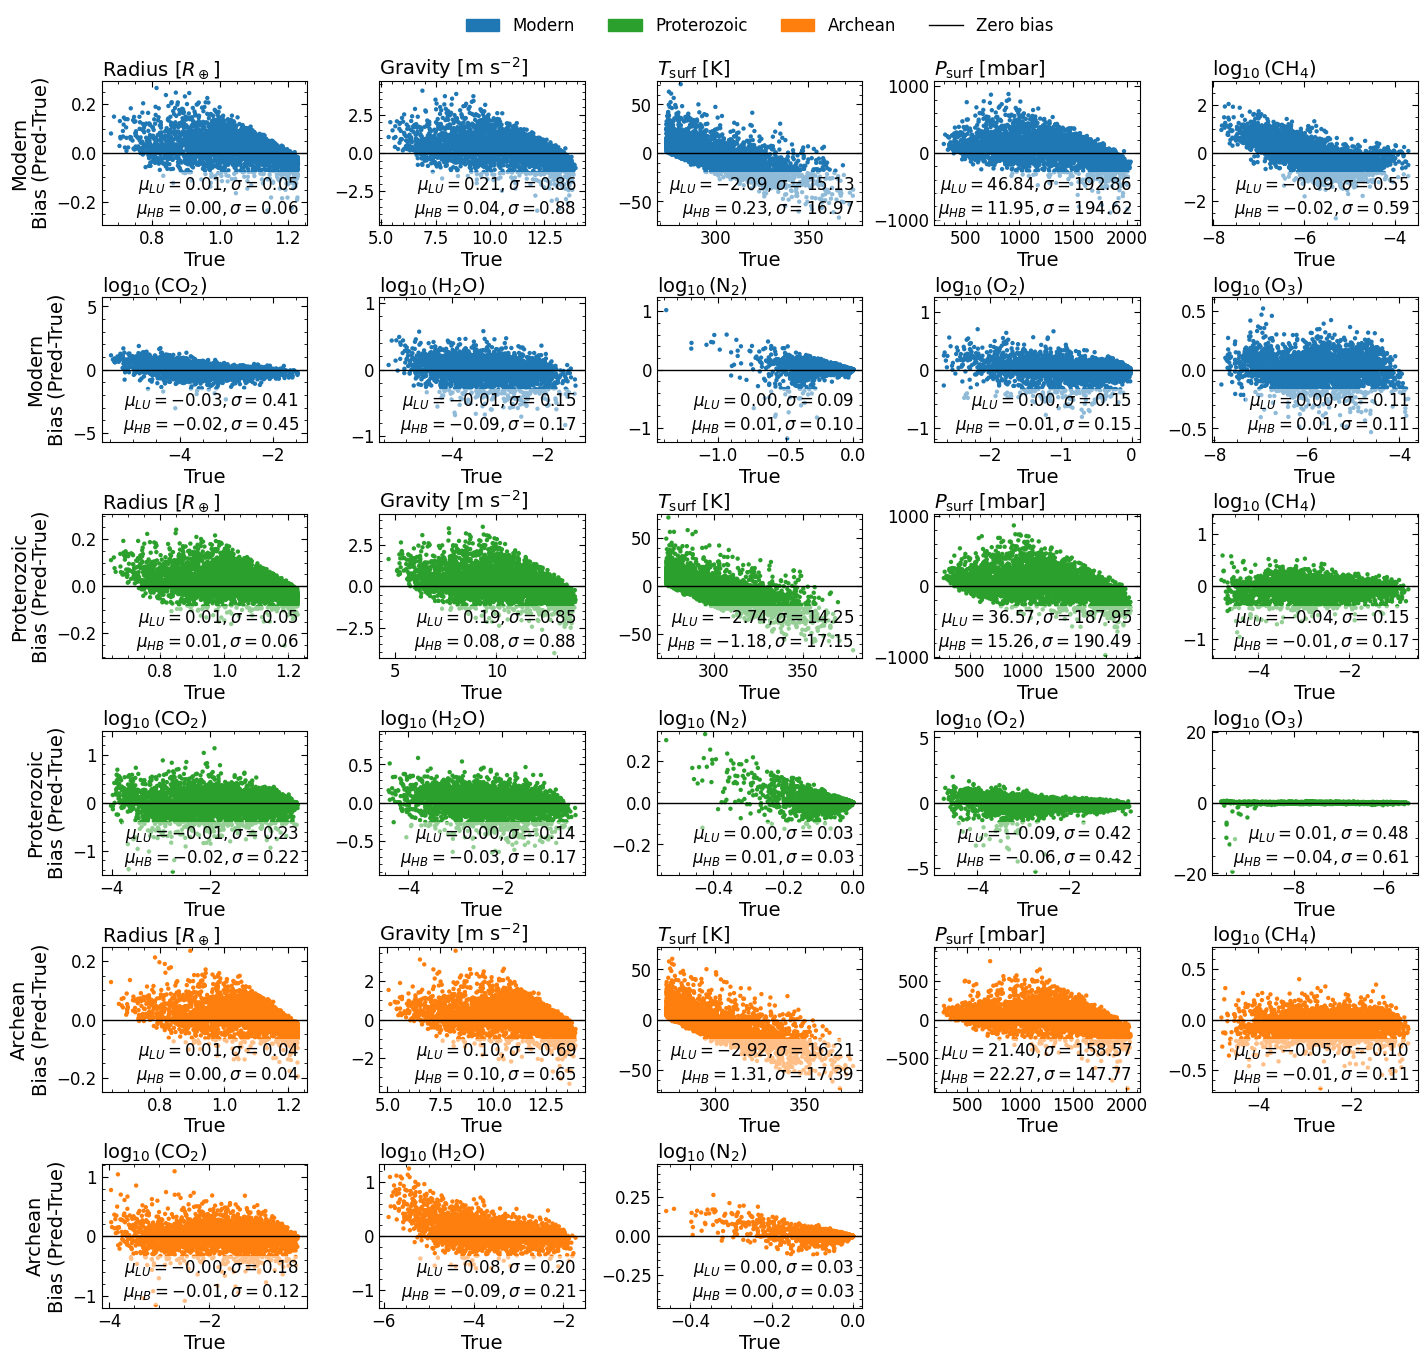

In [32]:
def _draw_bias_panel(
    ax,
    xL,
    yL,
    xH,
    yH,
    feat,
    era,
    sigma_levels=(1, 2, 3),
    is_top_row=False,
):
    color = ERA_COLORS[era]
    SCATTER_KW = dict(s=10, edgecolors="none", rasterized=True)

    resL = yL - xL
    resH = yH - xH if xH.size else np.array([])

    ax.scatter(xL, resL, color=color, **SCATTER_KW)
    ax.axhline(0, color="k", lw=1.0, zorder=5)

    sL = _sigma(resL)
    sH = _sigma(resH)

    # y limits: cover both telescopes' spread
    parts = []
    if resL.size:
        parts.append(np.abs(resL).max())
    if resH.size:
        parts.append(np.abs(resH).max())
    if np.isfinite(sL):
        parts.append(3.2 * sL)
    if np.isfinite(sH):
        parts.append(3.2 * sH)
    ymax = max(parts) if parts else 1.0
    if not np.isfinite(ymax) or ymax == 0:
        ymax = 1.0
    ax.set_ylim(-1.05 * ymax, 1.05 * ymax)

    muL = float(np.nanmean(resL)) if resL.size else np.nan
    muH = float(np.nanmean(resH)) if resH.size else np.nan
    ax.text(
        0.96,
        0.04,
        rf"$\mu_{{LU}}={_fmt(muL)},\sigma={_fmt(sL)}$"
        + "\n"
        + rf"$\mu_{{HB}}={_fmt(muH)},\sigma={_fmt(sH)}$",
        transform=ax.transAxes,
        fontsize=12,
        va="bottom",
        ha="right",
        bbox=dict(facecolor="white", alpha=0.50, edgecolor="none", pad=1.5),
    )

    ax.set_title(FEAT_LABELS[feat], pad=4, loc="left")

    ax.set_xlabel("True", labelpad=2)


def plot_bias_grid(
    df_lu, df_hb, sigma_levels=(1, 2, 3), outpath="fig_bias_grid.pdf", dpi=200
):
    fig, era_axes = _build_grid(fig_w=14, row_h=2.2, era_gap=0.5)
    FEAT_ROWS = [ROW0_FEATS, ROW1_FEATS]

    for era_idx, era in enumerate(ERA_ORDER):
        for row_in_era in range(2):
            feats_in_row = FEAT_ROWS[row_in_era]
            for col, feat in enumerate(feats_in_row):
                ax = era_axes[era_idx][row_in_era][col]

                excluded = (era in EXCLUDE) and (feat in EXCLUDE[era])
                if excluded:
                    ax.axis("off")
                    continue

                xL, yL = _xy(df_lu, era, feat)
                xH, yH = _xy(df_hb, era, feat)

                if xL.size == 0:
                    ax.axis("off")
                    continue

                _draw_bias_panel(
                    ax,
                    xL,
                    yL,
                    xH,
                    yH,
                    feat,
                    era,
                    sigma_levels=sigma_levels,
                    is_top_row=(row_in_era == 0),
                )
                if col == 0:
                    ax.set_ylabel(f"{ERA_TITLES[era]}\nBias (Pred-True)", labelpad=4)
                else:
                    ax.set_ylabel("")

    handles = [
        Patch(color=ERA_COLORS["modern"], label="Modern"),
        Patch(color=ERA_COLORS["proterozoic"], label="Proterozoic"),
        Patch(color=ERA_COLORS["archean"], label="Archean"),
        Line2D([0], [0], color="k", lw=1.0, label="Zero bias"),
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        ncol=len(handles),
        frameon=False,
        bbox_to_anchor=(0.52, 1.03),
    )

    if outpath:
        fig.savefig(outpath, dpi=dpi, bbox_inches="tight")
    return fig


fig2 = plot_bias_grid(
    results_df_LUVOIR,
    results_df_HABEX,
    outpath="../images/bias_grid.pdf",
)